# ML5: Decision Trees, Random Forests & Gradient Boosting
Продолжаем работу с датасетом [Don't Get Kicked!](https://www.kaggle.com/competitions/DontGetKicked/overview) (Kaggle), подготовленным на предыдущем этапе.

В этой части рассматриваются:
- Реализация деревьев решений и ансамблей (DecisionTree, RandomForest, ExtraTrees, GBDT).
- Сравнение собственных моделей с реализациями sklearn, LightGBM, CatBoost и XGBoost.
- Оценка качества по Gini и анализ переобучения.
--- 

In [53]:
import preprocessing as pp
import pandas as pd

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from trees import MyDecisionTreeClassifier, MyDecisionTreeRegressor, MyRandomForestClassifier, MyGBDTClassifier, MyExtraTreesClassifier

In [54]:
train_df = pd.read_csv('data/training.csv')

train_df_split, val_df_split, test_df_split = pp.preprocess_data(*pp.split_by_time(train_df))

In [55]:
for df in (train_df_split, val_df_split, test_df_split):
    print(df.shape)

(23059, 75)
(24104, 75)
(25820, 75)


In [56]:
train_df_split.head(5)

,IsBadBuy,PurchDate,VehYear,VehicleAge,Make,Model,Trim,SubModel,VehOdo,MMRAcquisitionAuctionAveragePrice,...,Color_GREY,Color_MAROON,Color_NOT AVAIL,Color_ORANGE,Color_OTHER,Color_PURPLE,Color_RED,Color_SILVER,Color_WHITE,Color_YELLOW
0,0,2009-01-05,2007,2,2542,90,4259,265,11.271389,8.890411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,2009-01-05,2005,4,4089,302,257,46,10.536805,8.391630,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0,2009-01-05,2004,5,4542,234,3263,1375,11.179981,8.038835,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0,2009-01-05,2006,3,5405,52,2842,171,11.148463,9.051462,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,2009-01-05,2004,5,4089,929,257,54,11.105423,8.037543,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### 2. Создадим класс Python для классификатора дерева решений и регрессора дерева решений (функция потерь MSE).
*Примечание: реализация классов **DecisionTreeClassifier** и **DecisionTreeRegressor** вынесена в модуль **trees.py**.* 

##### 3. При использовании модуля DecisionTree необходимо получить коэффициент Джини не менее 0,1 на проверочном наборе данных.

In [57]:
def learning_models(model, name, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)
    probs = model.predict_proba(X_val)

    if probs.ndim == 1:
        probabilities = probs
    else:
        probabilities = probs[:, 1]

    gini = abs(2 * roc_auc_score(y_val, probabilities) - 1)
    print(f"{name}: {gini:.4f}")

    return model, gini

In [58]:
size_cols  = [c for c in train_df_split.columns if 'Size' in c]
color_cols = [c for c in train_df_split.columns if 'Color' in c and c != 'Color_NOT AVAIL']
mmr_cols   = [c for c in train_df_split.columns if 'MMR' in c and c != 'MMR_Final']

feature_cols = train_df_split.columns.drop(['IsBadBuy', 'PurchDate', 'IsOnlineSale'] + size_cols + color_cols + mmr_cols)


X_train = train_df_split[feature_cols].values
y_train = train_df_split['IsBadBuy'].values

X_val = val_df_split[feature_cols].values
y_val = val_df_split['IsBadBuy'].values

X_test = test_df_split[feature_cols].values
y_test = test_df_split['IsBadBuy'].values

In [59]:
my_tree = learning_models(
    MyDecisionTreeClassifier(
        max_depth=5, 
        random_state=42
    ),
    'My_DecisionTreeClassifier',
    X_train, y_train,
    X_val, y_val
)

My_DecisionTreeClassifier: 0.4540


##### 4. Используем модуль DecisionTreeClassifier из библиотеки sklearn и проверим его производительность на validation. Лучше ли он, чем наш модуль? Если да, то почему?

In [60]:
sk_tree, sk_gini = learning_models(
    DecisionTreeClassifier(
        max_depth=5, 
        random_state=42
    ),
    'Sk_DecisionTreeClassifier',
    X_train, y_train,
    X_val, y_val
)

Sk_DecisionTreeClassifier: 0.4545


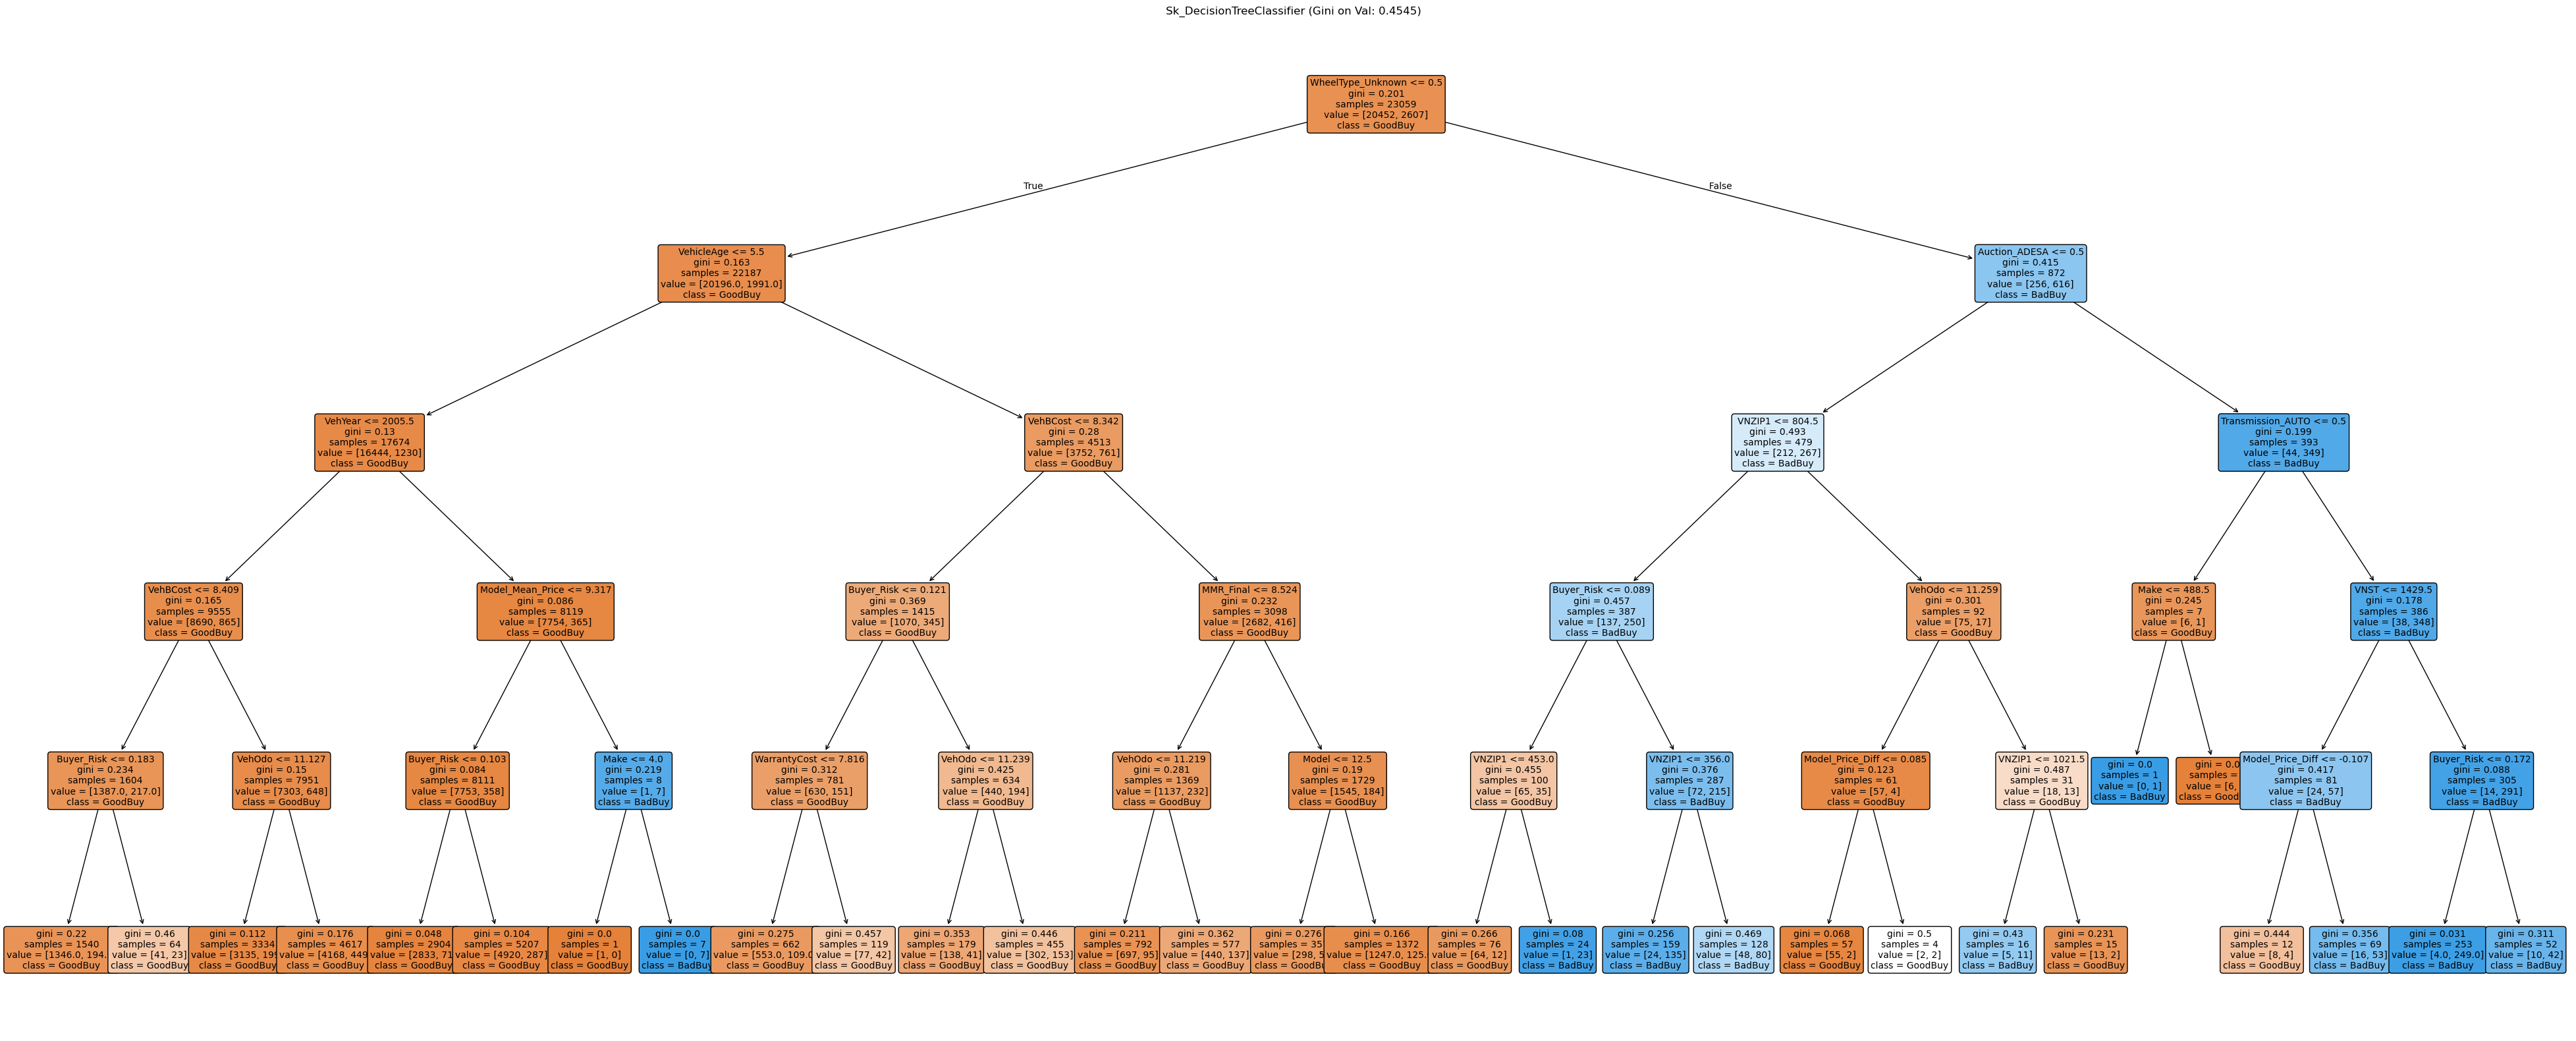

In [61]:
plt.figure(figsize=(50, 20))
plot_tree(
    sk_tree, 
    feature_names=feature_cols.tolist(), 
    class_names=['GoodBuy', 'BadBuy'],    
    filled=True,                         
    rounded=True,
    fontsize=10                         
)

plt.title(f"Sk_DecisionTreeClassifier (Gini on Val: {sk_gini:.4f})")
plt.show()

- **Ограничение количества порогов разбиения**    
  В sklearn дерево не перебирает все возможные *midpoints* между уникальными значениями признака.
  Вместо этого используется ограниченный набор порогов, чтобы ускорить обучение.
  Из‑за этого некоторые потенциально более точные разбиения могут быть пропущены.

 - **Ранняя остановка при малом улучшении impurity**    
Если очередное разбиение уменьшает *impurity* слишком слабо, sklearn прекращает делить узел.
Это снижает переобучение и ускоряет обучение, но иногда приводит к чуть менее точным деревьям.

 - **Внутренние ограничения глубины**    
Даже если явно указать *max_depth*, sklearn может не углубляться дальше,
если считает, что дальнейшее деление не даёт достаточного выигрыша.
Это делает модель более стабильной, но иногда менее точной.

 - **Ограничение минимального размера узла**  
Если в узле слишком мало объектов, sklearn не делит его дальше.
Это предотвращает переобучение, но может пропустить полезные разбиения.



##### 5. Реализуйте RandomForestClassifier и проверьте его производительность. Вам необходимо улучшить результат одного дерева и получить показатель Джини не менее 0,15 на проверочном наборе данных. Необходимо иметь возможность установить фиксированное начальное значение генератора случайных чисел.
*Примечание: реализация **RandomForestClassifier** вынесена в модуль **trees.py**.* 

In [62]:
my_random_forest = learning_models(
    MyRandomForestClassifier(
        n_estimators=30,
        max_depth=3,
        random_state=42
), 
    'My_RandomForest',
    X_train, y_train,
    X_val, y_val
)

My_RandomForest: 0.4761


In [63]:
sklearn_random_forest = learning_models(
    RandomForestClassifier(
        n_estimators=30,
        max_depth=7,
        random_state=42
    ),
    'Sklearn_RandomForest',
    X_train, y_train,
    X_val, y_val
)

Sklearn_RandomForest: 0.4862


##### 6. Используйте свой класс проектирования DecisionTree для классификатора GBDT. Этот класс должен иметь атрибуты max_depth , number_of_trees и max_features . Вам необходимо вычислить градиент функции потерь бинарной кросс-энтропии и реализовать инкрементальное обучение: обучить следующее дерево, используя результаты предыдущих деревьев.
*Примечание: реализация **DecisionTree** вынесена в модуль **trees.py**.* 

In [64]:
my_gbdt = learning_models(
    MyGBDTClassifier(
        max_depth=7,
        n_estimators=30,
        learning_rate=0.1,
        random_state=42
    ),
    'My_GBDT',
    X_train, y_train,
    X_val, y_val
)

My_GBDT: 0.4807


##### 7. Используем LightGBM, Catboost и XGBoost для обучения на обучающем наборе данных и прогнозирования на валидационном наборе. Доработаем алгоритмы для решения поставленной задачи и отметим ключевые различия между реализациями. Проанализируем особенности каждого алгоритма (как работает «категориальный признак» в Catboost, что такое режим DART в XGBoost)? Какая модель GBDT дает наилучший результат?

In [65]:
model_lgbm = LGBMClassifier(
    n_estimators=30, 
    max_depth=7, 
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgbm_res = learning_models(
    model_lgbm,
    "LGBM",
    X_train, y_train,
    X_val, y_val
)

model_xgb = XGBClassifier(
    n_estimators=30, 
    max_depth=7, 
    learning_rate=0.1, 
    random_state=42,
    verbosity=0,
    tree_method="hist"
)
xgb_res = learning_models(
    model_xgb,
    "XGBoost",
    X_train, y_train,
    X_val, y_val
)

model_cat = CatBoostClassifier(
    iterations=30,
    depth=7, 
    learning_rate=0.1, 
    random_state=42,
    verbose=False
)
cat_res = learning_models(
    model_cat,
    "CatBoost",
    X_train, y_train,     
    X_val, y_val
)

LGBM: 0.4712


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


XGBoost: 0.4759
CatBoost: 0.4807


Напомню, что наша предобработка признаков состояла из:
- **One-Hot Encoding** для признаков с небольшим количеством категорий:
```python
ohe_features = ['Size', 'TopThreeAmericanName', 'Nationality', 'Transmission', 'WheelType', 'Auction', 'Color']
```
- **Count Encoding** для признаков с высокой кардинальностью:
```python
count_cols = ['Make', 'Model', 'SubModel', 'Trim', 'VNST', 'VNZIP1']
```
##### 1. Почему CatBoost показал лучший результат на нашем кодировании?
- **Count Encoding**: Замена моделей и марок машин на их частоты создает признаки, в которых разные категории могут иметь одинаковые числовые значения. CatBoost использует симметричные деревья (Symmetric Trees), которые используют одно и то же условие разбиения на всем уровне дерева. Это не позволяет модели зацикливаться на единичных выбросах в частотах и заставляет её находить более общие закономерности в распределении машин, что критично для данного зашумленного датасета.

- **Устойчивость к разреженным данным**: One-Hot Encoding создал большое количество бинарных колонок (Color, Auction). LightGBM и XGBoost склонны быстро переобучаться на таких разреженных данных, выбирая случайные шумы в конкретных цветах или типах колес. CatBoost за счет более жесткой структуры дерева игнорирует статистически незначимые признаки, сохраняя высокую обобщающую способность.

##### 2. Особенности XGBoost и режим DART

**Суть алгоритма DART**: в классическом бустинге каждое следующее дерево исправляет ошибки всех предыдущих, что часто приводит к переобучению. В режиме *DART* при добавлении нового дерева алгоритм случайно выключает часть уже созданных деревьев. Это заставляет модель не полагаться на одно-два доминирующих дерева, а распределять вес предсказания по всему ансамблю. В условиях нашего кодирования, где Count Encoding может давать сильные, но ложные подсказки на трейне, *DART* помогает сделать модель более устойчивой к изменениям в тестовых данных.

In [66]:
model_xgb_dart = XGBClassifier(
    booster='dart',          
    rate_drop=0.2,           
    skip_drop=0.5,          
    n_estimators=30, 
    max_depth=3, 
    learning_rate=0.1, 
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

xgb_dart_res = learning_models(
    model_xgb_dart,
    "XGBoost_DART",
    X_train, y_train,
    X_val, y_val
)

XGBoost_DART: 0.4777


In [67]:
def gini_score(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    return 2 * auc - 1

gini_train = gini_score(model_xgb_dart, X_train, y_train)
gini_val = gini_score(model_xgb_dart, X_val, y_val)
gini_test = gini_score(model_xgb_dart, X_test, y_test)

print("Gini_train:", gini_train)
print("Gini_val:  ", gini_val)
print("Gini_test: ", gini_test)

Gini_train: 0.5390558307452944
Gini_val:   0.47774402266259686
Gini_test:  0.48943826101922405


##### 3. Различия в обучении (LightGBM vs XGBoost vs CatBoost)
- **LightGBM** (Leaf-wise): выбирает для разделения узел, дающий максимальное уменьшение ошибки. Это делает его самым быстрым, но в нашем случае алгоритм слишком глубоко подстраивался под специфические комбинации признаков (например, конкретный ZIP-код и частоту модели).
- **XGBoost** (Level-wise): cтроит дерево по уровням, что является более сбалансированным подходом и дает лучший контроль над сложностью модели.
- **CatBoost** (Symmetric): за счет симметричности деревьев обеспечивается самая сильная регуляризация. Модель тратит меньше ресурсов на подгонку под шум и больше на извлечение смысла из частотных характеристик машин и их технического состояния.

##### 8. Выберем лучшую модель и оценим коэффициент Джини для обучающей выборки, коэффициент Джини для валидационной выборки и коэффициент Джини для тестовой выборки. Есть ли снижение производительности при сравнении валидационной выборки с тестовой? Переобучается ли наша модель? 

In [68]:
best_cat = CatBoostClassifier(
    iterations=30,
    depth=7,
    learning_rate=0.05,
    random_state=42,
    verbose=False
)

best_cat.fit(X_train, y_train)

In [69]:
def gini_score(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    return 2 * auc - 1

gini_train = gini_score(best_cat, X_train, y_train)
gini_val = gini_score(best_cat, X_val, y_val)
gini_test = gini_score(best_cat, X_test, y_test)

print("Gini_train:", gini_train)
print("Gini_val:  ", gini_val)
print("Gini_test: ", gini_test)

Gini_train: 0.5478421093340373
Gini_val:   0.4845489648559971
Gini_test:  0.5011590215876836


Так как разбиение выполнялось по `PurchDate`, каждая выборка соответствует разным временным периодам. Валидационная выборка попала в более ранний участок временного ряда, где поведение покупателей и характеристики автомобилей ещё менялись, что отражает сезонность и временные колебания рынка. Тестовая выборка относится к более позднему периоду, где структура данных уже смещена относительно валидации, но при этом ближе к последним данным, на которых обучалась модель. Поэтому качество на тесте оказалось немного выше, чем на валидации. Разница объясняется временными эффектами и сезонностью данных, а не переобучением модели.

##### 9*. Реализуем ExtraTreesClassifier. Необходимо улучшить результат для одного дерева и получить коэффициент Джини не менее 0,12 на проверочном наборе данных.
*Примечание: реализация **ExtraTreesClassifier** вынесена в модуль **trees.py**.* 

In [70]:
my_extra_trees_classifier = learning_models(
    MyExtraTreesClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42
    ),
    'My_ExtraTreesClassifier',
    X_train, y_train,
    X_val, y_val
)

My_ExtraTreesClassifier: 0.4585


In [71]:
sklearn_extra_trees_classifier = learning_models(
    ExtraTreesClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
    ),
    'Sklearn_ExtraTreesClassifier',
    X_train, y_train,
    X_val, y_val
)

Sklearn_ExtraTreesClassifier: 0.4864
